# Регрессионный анализ: прогнозирование стоимости недвижимости  
## (Ridge Regression + XGBoost)

**Цель:**

1. Загрузить данные `all_v2.csv` о недвижимости в России за 2018–2021 гг.
2. Отфильтровать данные по региону `2661` — Санкт-Петербург и область.
3. Выполнить предварительную обработку данных:
   - удалить нетипичные объекты;
   - заменить некорректные значения количества комнат;
   - добавить новые признаки.
4. Провести анализ данных:
   - построить матрицу корреляции;
   - определить наиболее значимые признаки.
5. Закодировать категориальные признаки с помощью `Binary Encoder`.
6. Разделить данные на обучающую и тестовую выборки в пропорции 80/20.
7. Построить и обучить модели регрессии:
   - линейная регрессия с L2-регуляризацией `Ridge`;
   - модель градиентного бустинга `XGBoost`.
8. Оценить качество моделей с помощью метрик:
   - `RMSLE`;
   - `R²`;
   - `MAE`.
9. Сравнить результаты разных моделей.
10. Выполнить скоринг одного нового объекта недвижимости.

In [25]:
# 1. Импортируйте файл all_v2.csv, библиотеки sklearn, pandas, category_encoders, xgboost. Отфильтруйте 
#    по региону 2661 – Санкт-Петербург и область.
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_log_error, r2_score, mean_absolute_error
# Импорт BinaryEncoder для кодирования категориальных признаков
import category_encoders as ce
# Импорт модели XGBoost
from xgboost import XGBRegressor

df = pd.read_csv("all_v2.csv")
display(df.head())

# Информация о датасете: типы данных, количество непустых значений
df.info()
# Проверка размера исходного датасета
print("Размер исходного датасета:", df.shape)

# Фильтрация данных по региону 2661 — Санкт-Петербург и область
df = df[df["region"] == 2661].copy()

# Проверка размера датасета после фильтрации
print("Размер датасета после фильтрации по региону 2661:", df.shape)
display(df.head())

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
1,8650000,2018-02-27,12:04:54,55.683807,37.297405,81,3,5,24,2,69.1,12.0,1
2,4000000,2018-02-28,15:44:00,56.295250,44.061637,2871,1,5,9,3,66.0,10.0,1
3,1850000,2018-03-01,11:24:52,44.996132,39.074783,2843,4,12,16,2,38.0,5.0,11
4,5450000,2018-03-01,17:42:43,55.918767,37.984642,81,3,13,14,2,60.0,10.0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5477006 entries, 0 to 5477005
Data columns (total 13 columns):
 #   Column         Dtype  
---  ------         -----  
 0   price          int64  
 1   date           object 
 2   time           object 
 3   geo_lat        float64
 4   geo_lon        float64
 5   region         int64  
 6   building_type  int64  
 7   level          int64  
 8   levels         int64  
 9   rooms          int64  
 10  area           float64
 11  kitchen_area   float64
 12  object_type    int64  
dtypes: float64(4), int64(7), object(2)
memory usage: 543.2+ MB
Размер исходного датасета: (5477006, 13)
Размер датасета после фильтрации по региону 2661: (461820, 13)


,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
7,3600000,2018-03-04,20:52:38,59.875526,30.395457,2661,1,2,5,1,31.1,6.0,1
36,3200000,2018-04-10,16:10:12,59.827465,30.201827,2661,1,7,9,1,31.0,7.0,1
47,6500000,2018-04-23,11:47:58,59.988334,29.786928,2661,3,3,3,3,89.0,10.0,1
54,6300000,2018-04-28,17:47:24,59.911622,30.284556,2661,3,5,5,2,99.9,14.5,1


In [26]:
# 2. Оставьте только типовые объекты: S общ - 20-200 кв. м., S кухни 6-30 кв. м., Цена 1,5-50 млн.
print("Размер датасета до фильтрации типовых объектов:", df.shape)
df = df[
    (df["area"] >= 20) & (df["area"] <= 200) &
    (df["kitchen_area"] >= 6) & (df["kitchen_area"] <= 30) &
    (df["price"] >= 1_500_000) & (df["price"] <= 50_000_000)
].copy()

# Проверка размера датасета после фильтрации типовых объектов
print("Размер датасета после фильтрации типовых объектов:", df.shape)
display(df.head())

# Краткая статистика по основным числовым признакам
display(df[["price", "area", "kitchen_area"]].describe())

Размер датасета до фильтрации типовых объектов: (461820, 13)
Размер датасета после фильтрации типовых объектов: (410663, 13)


,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
7,3600000,2018-03-04,20:52:38,59.875526,30.395457,2661,1,2,5,1,31.1,6.0,1
36,3200000,2018-04-10,16:10:12,59.827465,30.201827,2661,1,7,9,1,31.0,7.0,1
47,6500000,2018-04-23,11:47:58,59.988334,29.786928,2661,3,3,3,3,89.0,10.0,1
54,6300000,2018-04-28,17:47:24,59.911622,30.284556,2661,3,5,5,2,99.9,14.5,1


,price,area,kitchen_area
count,4.106630e+05,410663.000000,410663.000000
mean,7.595275e+06,57.528256,12.565677
std,5.075850e+06,24.991515,4.722221
min,1.500000e+06,20.000000,6.000000
25%,4.590000e+06,38.600000,9.100000
50%,6.065766e+06,52.000000,11.500000
75%,8.745887e+06,68.400000,15.100000
max,5.000000e+07,200.000000,30.000000


In [27]:
# 3. Число комнат «-1» и «-2» замените на 0.
print("Уникальные значения rooms до замены:")
print(sorted(df["rooms"].unique()))

print("\nКоличество объектов с rooms = -1:", (df["rooms"] == -1).sum())
print("Количество объектов с rooms = -2:", (df["rooms"] == -2).sum())

# Замена значений -1 и -2 на 0
# Такие значения интерпретируются как студии или специальные планировки
df["rooms"] = df["rooms"].replace({-1: 0, -2: 0})

# Проверка уникальных значений признака rooms после замены
print("\nУникальные значения rooms после замены:")
print(sorted(df["rooms"].unique()))

# Проверка количества объектов по числу комнат после замены
print("\nКоличество объектов по числу комнат после замены:")
print(df["rooms"].value_counts().sort_index())

Уникальные значения rooms до замены:
[-2, -1, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Количество объектов с rooms = -1: 5009
Количество объектов с rooms = -2: 18

Уникальные значения rooms после замены:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Количество объектов по числу комнат после замены:
rooms
0      5027
1    165509
2    140224
3     84028
4     12713
5      2545
6       426
7       124
8        42
9        25
Name: count, dtype: int64


In [28]:
# 4. Добавьте признаки: Этаж квартиры/Этажность, Первый, Последний этаж, ratio = (S кухни/S общая).
# Если число комнат 0, то ratio = S общая.
df["level_ratio"] = df["level"] / df["levels"]

# Добавление бинарного признака: находится ли квартира на первом этаже
# 1 — первый этаж, 0 — не первый этаж
df["is_first_floor"] = (df["level"] == 1).astype(int)

# Добавление бинарного признака: находится ли квартира на последнем этаже
# 1 — последний этаж, 0 — не последний этаж
df["is_last_floor"] = (df["level"] == df["levels"]).astype(int)

# Добавление признака: отношение площади кухни к общей площади квартиры
df["ratio"] = df["kitchen_area"] / df["area"]

# Для объектов с количеством комнат 0 значение ratio заменяется на общую площадь
df.loc[df["rooms"] == 0, "ratio"] = df.loc[df["rooms"] == 0, "area"]

# Проверка новых признаков
display(df[[
    "level", 
    "levels", 
    "level_ratio", 
    "is_first_floor", 
    "is_last_floor", 
    "rooms", 
    "area", 
    "kitchen_area", 
    "ratio"
]].head(10))

# Краткая статистика по новым признакам
display(df[[
    "level_ratio", 
    "is_first_floor", 
    "is_last_floor", 
    "ratio"
]].describe())

# Проверка количества квартир на первом и последнем этажах
print("Количество объектов на первом этаже:")
print(df["is_first_floor"].value_counts())

print("\nКоличество объектов на последнем этаже:")
print(df["is_last_floor"].value_counts())

,level,levels,level_ratio,is_first_floor,is_last_floor,rooms,area,kitchen_area,ratio
0,8,10,0.800000,0,0,3,82.6,10.8,0.130751
7,2,5,0.400000,0,0,1,31.1,6.0,0.192926
36,7,9,0.777778,0,0,1,31.0,7.0,0.225806
47,3,3,1.000000,0,1,3,89.0,10.0,0.112360
54,5,5,1.000000,0,1,2,99.9,14.5,0.145145
66,7,12,0.583333,0,0,3,69.0,11.0,0.159420
69,14,14,1.000000,0,1,2,60.0,11.0,0.183333
76,2,17,0.117647,0,0,1,44.9,16.5,0.367483
98,3,4,0.750000,0,0,2,52.6,8.8,0.167300
106,1,6,0.166667,1,0,3,68.0,8.3,0.122059


,level_ratio,is_first_floor,is_last_floor,ratio
count,410663.000000,410663.000000,410663.000000,410663.000000
mean,0.541709,0.063865,0.085942,0.619171
std,0.282340,0.244513,0.280278,3.828430
min,0.032258,0.000000,0.000000,0.033021
25%,0.300000,0.000000,0.000000,0.166667
50%,0.538462,0.000000,0.000000,0.229032
75%,0.782609,0.000000,0.000000,0.292335
max,4.000000,1.000000,1.000000,195.800000


Количество объектов на первом этаже:
is_first_floor
0    384436
1     26227
Name: count, dtype: int64

Количество объектов на последнем этаже:
is_last_floor
0    375370
1     35293
Name: count, dtype: int64


In [29]:
# 5. Добавление временного признака без утечки данных
# Количество дней с момента самой ранней даты в наборе данных до даты рекламы

df["date"] = pd.to_datetime(df["date"])

# Проверка дат
print("Минимальная дата объявления:", df["date"].min())
print("Максимальная дата объявления:", df["date"].max())

# В качестве фиксированной даты отсчета используем минимальную дату в датасете
# Это не создает утечку данных, так как не использует будущую максимальную дату
reference_date = df["date"].min()

print("Дата отсчета:", reference_date)

# Новый временной признак: сколько дней прошло с начала периода наблюдений
df["days_from_start"] = (df["date"] - reference_date).dt.days

display(df[["date", "days_from_start"]].head(10))
display(df["days_from_start"].describe())

Минимальная дата объявления: 2018-02-19 00:00:00
Максимальная дата объявления: 2021-05-01 00:00:00
Дата отсчета: 2018-02-19 00:00:00


,date,days_from_start
0,2018-02-19,0
7,2018-03-04,13
36,2018-04-10,50
47,2018-04-23,63
54,2018-04-28,68
66,2018-05-22,92
69,2018-05-26,96
76,2018-06-02,103
98,2018-06-29,130
106,2018-07-04,135


count    410663.000000
mean        696.327237
std         277.338364
min           0.000000
25%         469.000000
50%         726.000000
75%         915.000000
max        1167.000000
Name: days_from_start, dtype: float64

Признак `ad_age` был заменен на более корректный временной признак `days_from_start`.

Он рассчитывается как количество дней между датой публикации объявления и минимальной датой в датасете:

`days_from_start = date - min(date)`

Минимальная дата объявления составила `2018-02-19`, максимальная — `2021-05-01`. Таким образом, диапазон признака составил от `0` до `1167` дней.

Среднее значение признака равно примерно `696.33`, медиана — `726`. Это показывает, что признак отражает положение объявления на временной шкале, а не длительность размещения объявления.

Корреляция признаков с price:


price              1.000000
area               0.780188
rooms              0.524654
kitchen_area       0.490240
days_from_start    0.146865
building_type      0.076815
level_ratio        0.073884
geo_lat            0.059786
is_last_floor      0.037881
object_type       -0.021540
ratio             -0.051590
is_first_floor    -0.060652
geo_lon           -0.069051
level             -0.076799
levels            -0.177535
region                  NaN
Name: price, dtype: float64

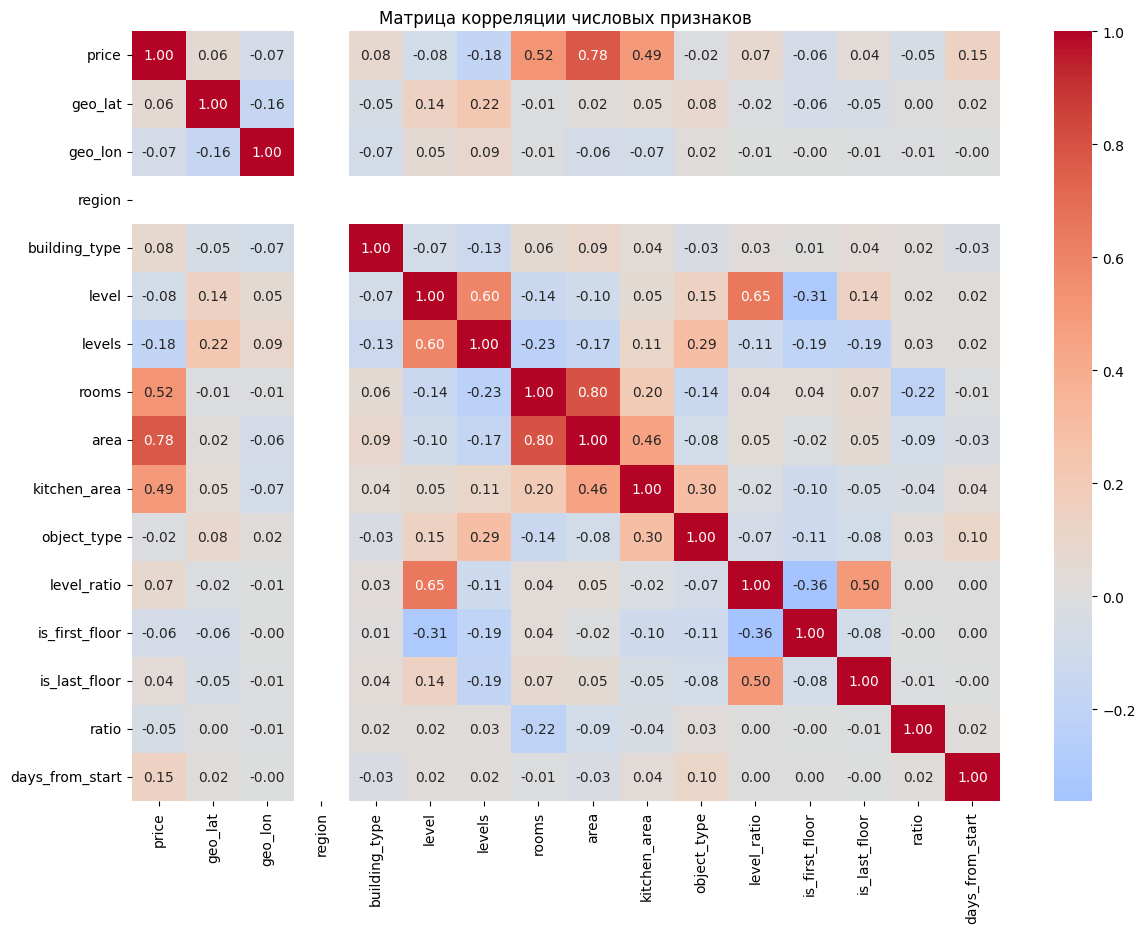

In [30]:
# 6. Постройте матрицу корреляции (pandas.corr()).
import matplotlib.pyplot as plt
import seaborn as sns

# Построение матрицы корреляции только для числовых признаков
corr_matrix = df.corr(numeric_only=True)

# Вывод корреляции признаков с целевой переменной price
price_corr = corr_matrix["price"].sort_values(ascending=False)

print("Корреляция признаков с price:")
display(price_corr)

# Визуализация матрицы корреляции
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Матрица корреляции числовых признаков")
plt.show()

Признак `region` после фильтрации принимает только одно значение — `2661`.  
Поэтому его корреляция с другими признаками не рассчитывается и отображается как `NaN`.


In [31]:
# 7. Подготовка списка признаков и категориальных колонок

target_col = "price"

# Колонки, которые не должны входить в признаки
drop_cols = ["price", "date", "time", "region"]

# Категориальные признаки для кодирования
categorical_cols = ["building_type", "object_type"]

print("Целевая переменная:", target_col)
print("Колонки, исключенные из признаков:", drop_cols)
print("Категориальные признаки:", categorical_cols)

# Проверка уникальных значений категориальных признаков на всем датасете
# Это только анализ, не обучение encoder
for col in categorical_cols:
    print(f"\nУникальные значения {col}:")
    print(sorted(df[col].dropna().unique()))

Целевая переменная: price
Колонки, исключенные из признаков: ['price', 'date', 'time', 'region']
Категориальные признаки: ['building_type', 'object_type']

Уникальные значения building_type:
[0, 1, 2, 3, 4, 5]

Уникальные значения object_type:
[1, 11]


In [32]:
# 8. Разделение данных на обучающую и тестовую выборки по времени

# Сортируем данные по дате объявления
df = df.sort_values("date").reset_index(drop=True)

split_index = int(len(df) * 0.8)
split_date = df.loc[split_index, "date"]

train_df = df[df["date"] < split_date].copy()
test_df = df[df["date"] >= split_date].copy()

print("Дата границы разбиения:", split_date)

print("Размер train:", train_df.shape)
print("Размер test:", test_df.shape)

print("Период train:")
print(train_df["date"].min(), "-", train_df["date"].max())

print("Период test:")
print(test_df["date"].min(), "-", test_df["date"].max())

print("Доля train:", round(len(train_df) / len(df), 3))
print("Доля test:", round(len(test_df) / len(df), 3))

Дата границы разбиения: 2020-10-05 00:00:00
Размер train: (328259, 18)
Размер test: (82404, 18)
Период train:
2018-02-19 00:00:00 - 2020-10-04 00:00:00
Период test:
2020-10-05 00:00:00 - 2021-05-01 00:00:00
Доля train: 0.799
Доля test: 0.201


In [33]:
# 8.1 Формирование матриц признаков и целевой переменной

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target_col]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target_col]

print("Размер X_train до кодирования:", X_train.shape)
print("Размер X_test до кодирования:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)

Размер X_train до кодирования: (328259, 14)
Размер X_test до кодирования: (82404, 14)
Размер y_train: (328259,)
Размер y_test: (82404,)


In [34]:
# 8.2 Кодирование категориальных признаков после временного разбиения

import category_encoders as ce

encoder = ce.BinaryEncoder(cols=categorical_cols)

# Обучаем encoder только на обучающей выборке
X_train_encoded = encoder.fit_transform(X_train)

# Тестовую выборку только трансформируем
X_test_encoded = encoder.transform(X_test)

print("Размер X_train после кодирования:", X_train_encoded.shape)
print("Размер X_test после кодирования:", X_test_encoded.shape)

print("\nСписок признаков после кодирования:")
print(X_train_encoded.columns.tolist())

display(X_train_encoded.head())

Размер X_train после кодирования: (328259, 17)
Размер X_test после кодирования: (82404, 17)

Список признаков после кодирования:
['geo_lat', 'geo_lon', 'building_type_0', 'building_type_1', 'building_type_2', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'object_type_0', 'object_type_1', 'level_ratio', 'is_first_floor', 'is_last_floor', 'ratio', 'days_from_start']


,geo_lat,geo_lon,building_type_0,building_type_1,building_type_2,level,levels,rooms,area,kitchen_area,object_type_0,object_type_1,level_ratio,is_first_floor,is_last_floor,ratio,days_from_start
0,59.805808,30.376141,0,0,1,8,10,3,82.6,10.8,0,1,0.800000,0,0,0.130751,0
1,59.875526,30.395457,0,0,1,2,5,1,31.1,6.0,0,1,0.400000,0,0,0.192926,13
2,59.827465,30.201827,0,0,1,7,9,1,31.0,7.0,0,1,0.777778,0,0,0.225806,50
3,59.988334,29.786928,0,1,0,3,3,3,89.0,10.0,0,1,1.000000,0,1,0.112360,63
4,59.911622,30.284556,0,1,0,5,5,2,99.9,14.5,0,1,1.000000,0,1,0.145145,68


In [35]:
# 9.1 Стандартизируйте числовые признаки и постройте модель линейной регрессии с L2-регуляризацией
# sklearn.linear_model.Ridge

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Создание копий данных для Ridge-модели
X_train_ridge = X_train.copy()
X_test_ridge = X_test.copy()

# Числовые признаки, которые нужно стандартизировать
# Бинарные признаки после кодирования и признаки 0/1 стандартизировать не обязательно
numeric_cols = [
    "geo_lat",
    "geo_lon",
    "level",
    "levels",
    "rooms",
    "area",
    "kitchen_area",
    "level_ratio",
    "ratio",
    "days_from_start"
]

# На случай, если какого-то признака нет в данных
numeric_cols = [col for col in numeric_cols if col in X_train_ridge.columns]

print("Числовые признаки для стандартизации:")
print(numeric_cols)

# Создание StandardScaler
scaler = StandardScaler()

# Обучаем scaler только на обучающей выборке
X_train_ridge[numeric_cols] = scaler.fit_transform(X_train_ridge[numeric_cols])

# Тестовую выборку только трансформируем
X_test_ridge[numeric_cols] = scaler.transform(X_test_ridge[numeric_cols])

# Создание модели Ridge-регрессии с L2-регуляризацией
ridge_model = Ridge(alpha=1.0, random_state=42)

# Обучение модели
ridge_model.fit(X_train_ridge, y_train)

# Предсказание на тестовой выборке
y_pred_ridge = ridge_model.predict(X_test_ridge)

# Оценка качества модели
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression results:")
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)
print("R2:", r2_ridge)

Числовые признаки для стандартизации:
['geo_lat', 'geo_lon', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'level_ratio', 'ratio', 'days_from_start']
Ridge Regression results:
MAE: 2129636.8007756006
RMSE: 3485805.31558589
R2: 0.6070398164306798


In [36]:
# 9.2 Постройте модель XGBoost (стандартизировать необязательно).
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Создание модели XGBoost
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

# Обучение модели
xgb_model.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred_xgb = xgb_model.predict(X_test)

# Оценка качества модели
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost results:")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

XGBoost results:
MAE: 1632753.6337571598
RMSE: 2546440.3459102456
R2: 0.7902947488356404


Ridge Regression metrics:
Train RMSLE: 0.5415538512934057
Test RMSLE: 0.311486884996503
Train R2: 0.6952805263716543
Test R2: 0.6070398164306798
Train MAE: 1567788.9563756979
Test MAE: 2129636.8007756006

XGBoost metrics:
Train RMSLE: 0.1635126883517048
Test RMSLE: 0.2281199976369046
Train R2: 0.9083134542561828
Test R2: 0.7902947488356404
Train MAE: 807232.8074462543
Test MAE: 1632753.6337571598


,Model,Dataset,RMSLE,R2,MAE
0,Ridge,Train,0.541554,0.695281,1.567789e+06
1,Ridge,Test,0.311487,0.607040,2.129637e+06
2,XGBoost,Train,0.163513,0.908313,8.072328e+05
3,XGBoost,Test,0.228120,0.790295,1.632754e+06


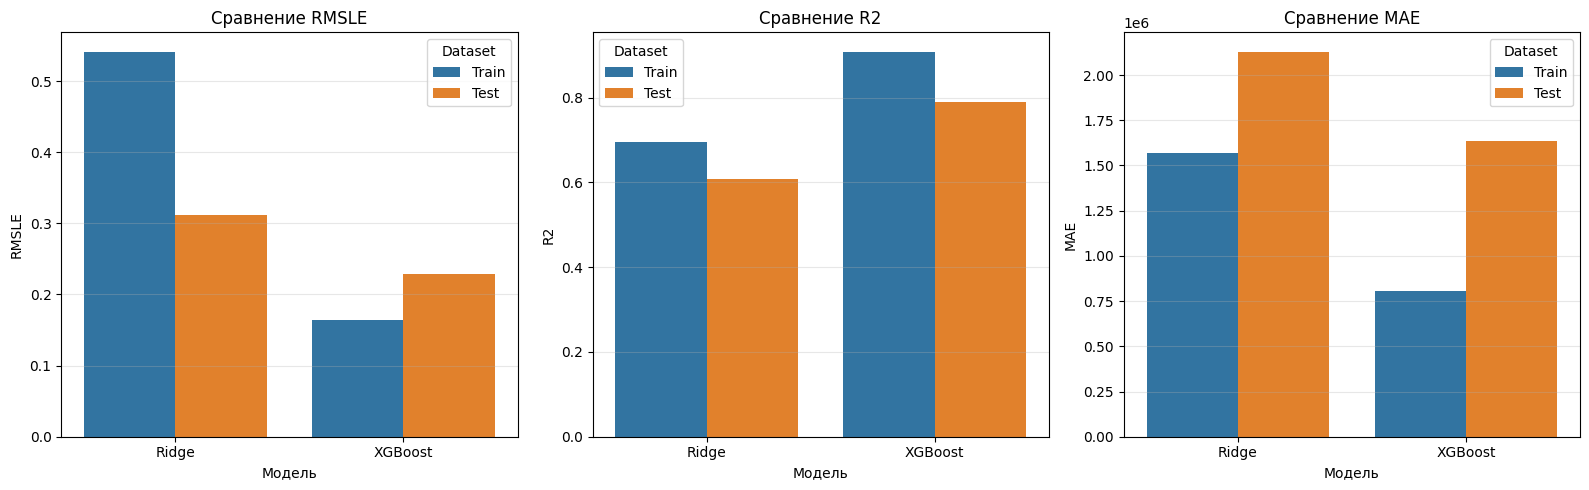

In [37]:
# 10. Рассчитайте регрессионные метрики RMSLE, R2, MAE
# для обучающей и тестовой выборок (sklearn.metrics)

from sklearn.metrics import mean_squared_log_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Функция для расчета RMSLE
def rmsle(y_true, y_pred):
    # RMSLE нельзя считать для отрицательных предсказаний,
    # поэтому заменяем отрицательные значения на 0
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))


# =====================================================
# Метрики для Ridge Regression
# =====================================================

# Предсказания Ridge на обучающей выборке
y_train_pred_ridge = ridge_model.predict(X_train_ridge)

# Предсказания Ridge на тестовой выборке
y_test_pred_ridge = ridge_model.predict(X_test_ridge)

# Расчет метрик Ridge
ridge_train_rmsle = rmsle(y_train, y_train_pred_ridge)
ridge_test_rmsle = rmsle(y_test, y_test_pred_ridge)

ridge_train_r2 = r2_score(y_train, y_train_pred_ridge)
ridge_test_r2 = r2_score(y_test, y_test_pred_ridge)

ridge_train_mae = mean_absolute_error(y_train, y_train_pred_ridge)
ridge_test_mae = mean_absolute_error(y_test, y_test_pred_ridge)


# =====================================================
# Метрики для XGBoost
# =====================================================

# Предсказания XGBoost на обучающей выборке
y_train_pred_xgb = xgb_model.predict(X_train)

# Предсказания XGBoost на тестовой выборке
y_test_pred_xgb = xgb_model.predict(X_test)

# Расчет метрик XGBoost
xgb_train_rmsle = rmsle(y_train, y_train_pred_xgb)
xgb_test_rmsle = rmsle(y_test, y_test_pred_xgb)

xgb_train_r2 = r2_score(y_train, y_train_pred_xgb)
xgb_test_r2 = r2_score(y_test, y_test_pred_xgb)

xgb_train_mae = mean_absolute_error(y_train, y_train_pred_xgb)
xgb_test_mae = mean_absolute_error(y_test, y_test_pred_xgb)


# =====================================================
# Вывод результатов
# =====================================================

print("Ridge Regression metrics:")
print("Train RMSLE:", ridge_train_rmsle)
print("Test RMSLE:", ridge_test_rmsle)
print("Train R2:", ridge_train_r2)
print("Test R2:", ridge_test_r2)
print("Train MAE:", ridge_train_mae)
print("Test MAE:", ridge_test_mae)

print("\nXGBoost metrics:")
print("Train RMSLE:", xgb_train_rmsle)
print("Test RMSLE:", xgb_test_rmsle)
print("Train R2:", xgb_train_r2)
print("Test R2:", xgb_test_r2)
print("Train MAE:", xgb_train_mae)
print("Test MAE:", xgb_test_mae)


# =====================================================
# Сравнительная таблица
# =====================================================

results = pd.DataFrame({
    "Model": ["Ridge", "Ridge", "XGBoost", "XGBoost"],
    "Dataset": ["Train", "Test", "Train", "Test"],
    "RMSLE": [
        ridge_train_rmsle,
        ridge_test_rmsle,
        xgb_train_rmsle,
        xgb_test_rmsle
    ],
    "R2": [
        ridge_train_r2,
        ridge_test_r2,
        xgb_train_r2,
        xgb_test_r2
    ],
    "MAE": [
        ridge_train_mae,
        ridge_test_mae,
        xgb_train_mae,
        xgb_test_mae
    ]
})

display(results)


# =====================================================
# Визуализация метрик
# =====================================================

plt.figure(figsize=(16, 5))

# RMSLE
plt.subplot(1, 3, 1)
sns.barplot(data=results, x="Model", y="RMSLE", hue="Dataset")
plt.title("Сравнение RMSLE")
plt.ylabel("RMSLE")
plt.xlabel("Модель")
plt.grid(axis="y", alpha=0.3)

# R2
plt.subplot(1, 3, 2)
sns.barplot(data=results, x="Model", y="R2", hue="Dataset")
plt.title("Сравнение R2")
plt.ylabel("R2")
plt.xlabel("Модель")
plt.grid(axis="y", alpha=0.3)

# MAE
plt.subplot(1, 3, 3)
sns.barplot(data=results, x="Model", y="MAE", hue="Dataset")
plt.title("Сравнение MAE")
plt.ylabel("MAE")
plt.xlabel("Модель")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# 11. Сравните результаты от разных моделей.
# Расчет улучшения XGBoost относительно Ridge на тестовой выборке

mae_improvement = (ridge_test_mae - xgb_test_mae) / ridge_test_mae * 100
rmsle_improvement = (ridge_test_rmsle - xgb_test_rmsle) / ridge_test_rmsle * 100
r2_improvement = (xgb_test_r2 - ridge_test_r2) / ridge_test_r2 * 100

print("Улучшение XGBoost относительно Ridge на тестовой выборке:")
print("MAE improvement:", round(mae_improvement, 2), "%")
print("RMSLE improvement:", round(rmsle_improvement, 2), "%")
print("R2 improvement:", round(r2_improvement, 2), "%")

Улучшение XGBoost относительно Ridge на тестовой выборке:
MAE improvement: 23.33 %
RMSLE improvement: 26.76 %
R2 improvement: 30.19 %


,feature,importance
0,area,0.317823
1,rooms,0.244745
2,kitchen_area,0.098299
3,ratio,0.093099
4,levels,0.059327
5,building_type,0.040873
6,geo_lat,0.032707
7,geo_lon,0.024170
8,object_type,0.019172
9,days_from_start,0.018640


C:\Users\Administrator\AppData\Local\Temp\ipykernel_24940\3089515598.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


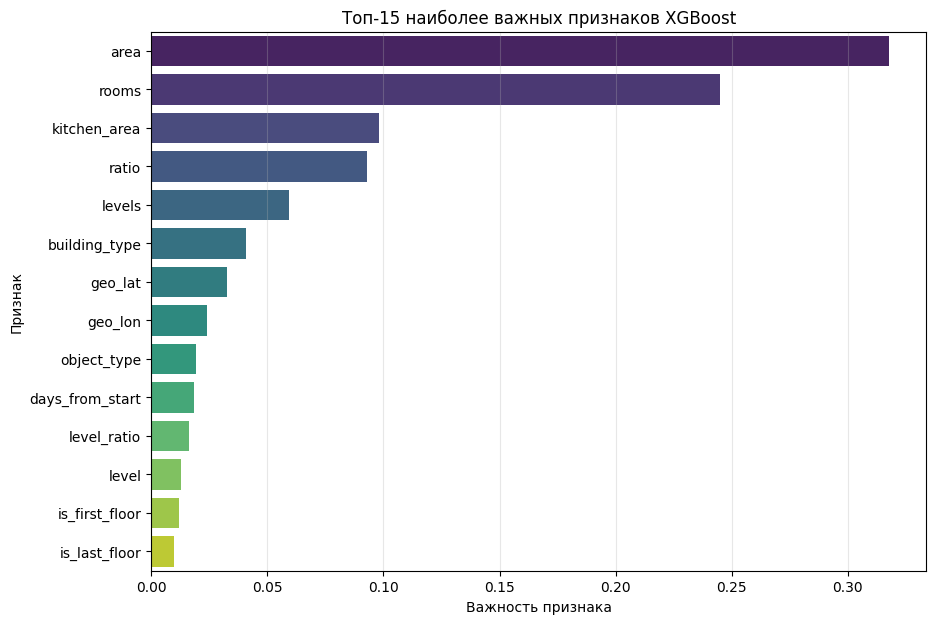

In [39]:
# 12. Посмотрите свойство feature_importances_ и проведите анализ значимых признаков

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Получение важности признаков из модели XGBoost
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
})

# Сортировка признаков по важности
feature_importances = feature_importances.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

# Вывод таблицы важности признаков
display(feature_importances)

# Топ-15 наиболее важных признаков
top_features = feature_importances.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    palette="viridis"
)

plt.title("Топ-15 наиболее важных признаков XGBoost")
plt.xlabel("Важность признака")
plt.ylabel("Признак")
plt.grid(axis="x", alpha=0.3)
plt.show()

13. Обсуждение временного признака days_from_start
Изначально признак ad_age мог создавать риск утечки данных, так как он рассчитывался относительно максимальной даты в датасете и фактически использовал информацию из будущего.

После исправления вместо него был создан признак days_from_start. Он показывает, сколько дней прошло от минимальной даты в датасете до даты публикации объявления:

days_from_start = date - min(date)

Этот признак не показывает давность объявления на рынке, а отражает положение объявления на временной шкале. Он может быть полезен, так как учитывает изменение рыночной ситуации во времени.

Для снижения риска утечки данных данные были разделены не случайно, а по времени: более ранние объявления попали в обучающую выборку, а более поздние — в тестовую.

Итог: признак ad_age был заменен на более корректный days_from_start, а разбиение данных выполнено по времени. Это делает оценку модели более честной и ближе к реальному сценарию прогнозирования.

In [41]:
# 14. Сделайте скоринг одного нового объекта
# Скоринг квартиры в регионе 2661 — Санкт-Петербург и област
# Создание нового объекта недвижимости
# Пример квартиры в Санкт-Петербурге

new_flat = pd.DataFrame([{
    "area": 45,
    "rooms": 2,
    "kitchen_area": 8,
    "level": 5,
    "levels": 9,
    "geo_lat": 59.9343,
    "geo_lon": 30.3351,
    "days_from_start": 10,
    "ratio": 8 / 45,
    "level_ratio": 5 / 9,
    "is_first_floor": 0,

    # One-hot признаки типа здания
    "building_type_0": 0,
    "building_type_1": 1,
    "building_type_2": 0,
    "building_type_3": 0,
    "building_type_4": 0,
    "building_type_5": 0,

    # One-hot признаки типа объекта
    "object_type_0": 1,
    "object_type_1": 0,
    "object_type_2": 0
}])

# Приведение нового объекта к структуре обучающей выборки
new_flat = new_flat.reindex(columns=X_train.columns, fill_value=0)

display(new_flat)

# Прогноз цены с помощью лучшей модели XGBoost
predicted_price_xgb = xgb_model.predict(new_flat)

print("Прогнозируемая стоимость квартиры по модели XGBoost:")
print(round(predicted_price_xgb[0], 2), "руб.")

,geo_lat,geo_lon,building_type,level,levels,rooms,area,kitchen_area,object_type,level_ratio,is_first_floor,is_last_floor,ratio,days_from_start
0,59.9343,30.3351,0,5,9,2,45,8,0,0.555556,0,0,0.177778,10


Прогнозируемая стоимость квартиры по модели XGBoost:
6509661.0 руб.


## вывод

В работе была построена модель для прогнозирования стоимости недвижимости в регионе 2661 — Санкт-Петербург и область.

Данные были очищены и отфильтрованы: оставлены типовые объекты по площади, площади кухни и цене, а некорректные значения количества комнат -1 и -2 заменены на 0.

Были добавлены новые признаки: отношение этажа к общей этажности, признаки первого и последнего этажа, отношение площади кухни к общей площади и временной признак days_from_start.

Категориальные признаки были закодированы, а данные разделены на обучающую и тестовую выборки по времени в пропорции примерно 80/20. Это позволило снизить риск утечки данных.

Для прогнозирования были обучены две модели: Ridge Regression и XGBoost Regressor. По результатам сравнения XGBoost показал лучшее качество, так как лучше учитывает нелинейные зависимости между признаками.

Наиболее важными признаками оказались общая площадь area, этажность levels, количество комнат rooms, площадь кухни kitchen_area, координаты geo_lat, geo_lon и временной признак days_from_start.

В целом XGBoost можно считать более подходящей моделью для данной задачи, однако при практическом использовании важно следить, чтобы все признаки были доступны на момент прогноза и не приводили к утечке данных.
